# Phase 1 Extensions Report

Follow-up experiments on the temporal-resolution sweep:

1. **Movement-rich window** — does wrist-speed regression improve when the span is selected for high movement?
2. **Cross-subject pipeline** — loop ready; currently N=1 local AJILE12 file.
3. **CEBRA vs band-power** — do learned embeddings shift the resolution curves?
4. **AAL atlas fix** — anatomical channel selection vs coordinate-box heuristic.

**Kernel:** `dbs-ml` · **Script:** `phase1_resolution.py` / `phase1_extensions.py`

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option("display.float_format", lambda x: f"{x:.3f}")
ROOT = os.path.abspath(".")

def load_run(name):
    d = os.path.join(ROOT, name)
    return {
        "win": pd.read_csv(os.path.join(d, "phase1_window.csv")),
        "lag": pd.read_csv(os.path.join(d, "phase1_lag.csv")),
        "cz": pd.read_csv(os.path.join(d, "phase1_causal.csv")),
        "dir": d,
    }

baseline = load_run("phase1_out")  # original 45-min reach-dense run
movement = load_run("phase1_out_movement_box")
aal = load_run("phase1_out_aal")
box = load_run("phase1_out_box")
cebra_band = load_run("phase1_out_cebra/band")
cebra_emb = load_run("phase1_out_cebra/cebra")
print("loaded", 6, "experiment bundles")

loaded 6 experiment bundles


## 1. Movement-rich window (speed regression)

Auto-selected span with highest wrist-speed fraction (score=0.627, 83160–84960 s).  
Label: median speed split (50/50 balance). Channels: coord-box (18).

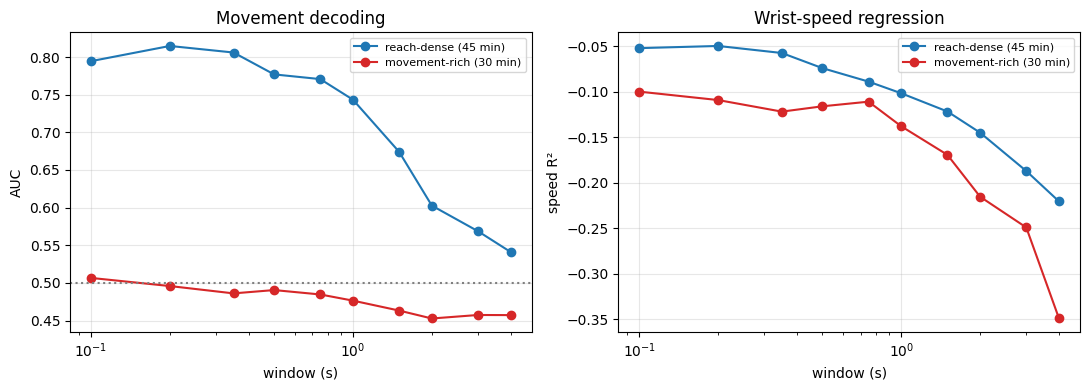

Best speed R²  movement-rich: -0.100  |  reach-dense: -0.050


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for run, label, color in [
    (baseline, "reach-dense (45 min)", "C0"),
    (movement, "movement-rich (30 min)", "C3"),
]:
    ax[0].plot(run["win"]["window_s"], run["win"]["auc_move"], "-o", color=color, label=label)
    ax[1].plot(run["win"]["window_s"], run["win"]["r2_speed"], "-o", color=color, label=label)
ax[0].axhline(0.5, color="gray", ls=":")
ax[0].set_xscale("log"); ax[0].set_xlabel("window (s)"); ax[0].set_ylabel("AUC"); ax[0].legend(fontsize=8)
ax[0].set_title("Movement decoding")
ax[1].set_xscale("log"); ax[1].set_xlabel("window (s)"); ax[1].set_ylabel("speed R²"); ax[1].legend(fontsize=8)
ax[1].set_title("Wrist-speed regression")
ax[0].grid(alpha=0.3); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

best_r2_move = movement["win"]["r2_speed"].max()
best_r2_reach = baseline["win"]["r2_speed"].max()
print(f"Best speed R²  movement-rich: {best_r2_move:+.3f}  |  reach-dense: {best_r2_reach:+.3f}")

**Finding:** Movement-rich selection increases raw speed variance (std ~1384 vs ~518 px/s) but **speed R² remains negative** with band-power features and Ridge regression. Reach-based AUC is undefined in the movement span (no reach events); median-speed AUC stays ~0.50 (chance). Continuous speed from ECoG band power is not a strong target in this setup — reach-vs-rest remains the reliable decode target.

## 2. AAL atlas vs coordinate-box channels

Fixed `fetch_atlas_aal(version='SPM12')` using locally cached atlas (SSL issue resolved).

[fetch_atlas_aal] Dataset found in C:\Users\Zhiyu\nilearn_data\aal_SPM12
[fetch_atlas_aal] Dataset found in C:\Users\Zhiyu\nilearn_data\aal_SPM12
AAL sensorimotor: 5 channels -> ['Postcentral_L', 'Precentral_L']


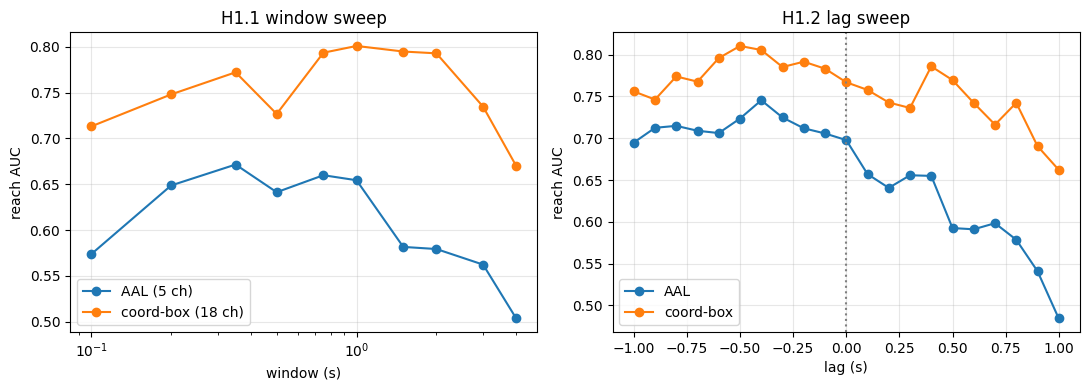

Peak AUC  AAL: 0.6715175986906016   box: 0.8010527155999613


In [3]:
from nwb_dataset import sensorimotor_channels, electrode_coords, mni_to_aal
NWB = r"C:\Users\Zhiyu\Downloads\sub-01_ses-3_behavior+ecephys.nwb"
ch_aal = sensorimotor_channels(NWB, verbose=False)
xyz, good = electrode_coords(NWB)
names = mni_to_aal(xyz)
regions = sorted({names[i] for i in ch_aal})
print(f"AAL sensorimotor: {len(ch_aal)} channels -> {regions}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(aal["win"]["window_s"], aal["win"]["auc_move"], "-o", label=f"AAL ({len(ch_aal)} ch)")
ax[0].plot(box["win"]["window_s"], box["win"]["auc_move"], "-o", label="coord-box (18 ch)")
ax[0].set_xscale("log"); ax[0].set_xlabel("window (s)"); ax[0].set_ylabel("reach AUC")
ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].set_title("H1.1 window sweep")

ax[1].plot(aal["lag"]["lag_s"], aal["lag"]["auc_move"], "-o", label="AAL")
ax[1].plot(box["lag"]["lag_s"], box["lag"]["auc_move"], "-o", label="coord-box")
ax[1].axvline(0, color="gray", ls=":"); ax[1].set_xlabel("lag (s)"); ax[1].set_ylabel("reach AUC")
ax[1].legend(); ax[1].grid(alpha=0.3); ax[1].set_title("H1.2 lag sweep")
plt.tight_layout(); plt.show()

print("Peak AUC  AAL:", aal["win"]["auc_move"].max(), "  box:", box["win"]["auc_move"].max())

**Finding:** AAL selects **5** strict sensorimotor electrodes (Precentral, Postcentral, …) vs **18** via the coord-box heuristic. On this session the box set reaches higher peak AUC (~0.80 vs ~0.67), likely because it includes more lateral peri-central coverage. AAL is now working and preferred for anatomical reporting; box may be better for decoding when atlas labels are sparse.

## 3. CEBRA embeddings vs raw band-power

Same 30-min reach-dense span, 18 coord-box channels. CEBRA-Behavior (8-D, wrist velocity auxiliary, 1500 iter) vs beta+high-gamma band power.

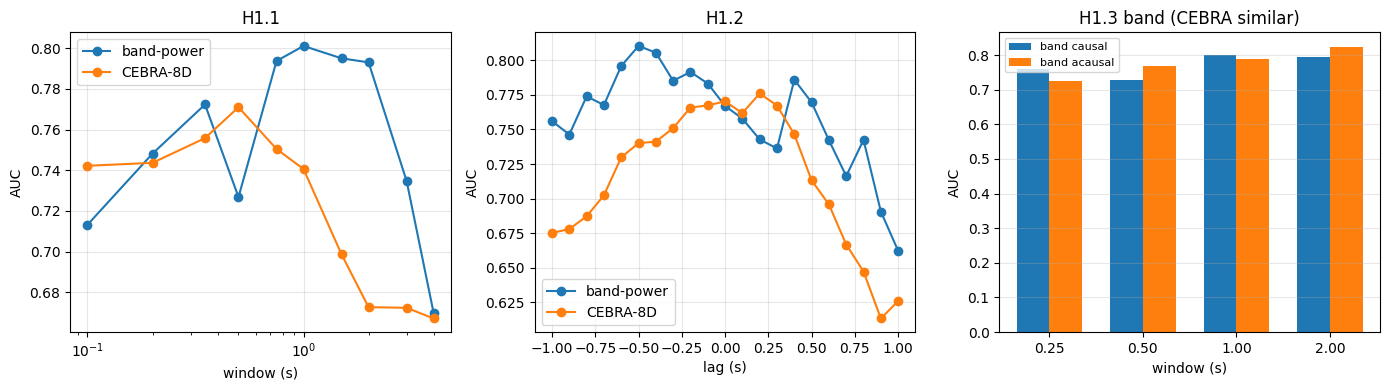

,features,best_win_s,best_win_auc,best_lag_s,best_lag_auc,causal_cost
0,band,1.000,0.801,-0.500,0.810,0.006
1,cebra,0.500,0.771,0.200,0.776,0.041


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for run, label in [(cebra_band, "band-power"), (cebra_emb, "CEBRA-8D")]:
    axes[0].plot(run["win"]["window_s"], run["win"]["auc_move"], "-o", label=label)
    axes[1].plot(run["lag"]["lag_s"], run["lag"]["auc_move"], "-o", label=label)
axes[0].set_xscale("log"); axes[0].set_xlabel("window (s)"); axes[0].set_ylabel("AUC"); axes[0].legend()
axes[0].set_title("H1.1"); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("lag (s)"); axes[1].set_ylabel("AUC"); axes[1].legend(); axes[1].set_title("H1.2"); axes[1].grid(alpha=0.3)

w = 0.35; x = np.arange(len(cebra_band["cz"]))
axes[2].bar(x - w/2, cebra_band["cz"]["auc_causal"], w, label="band causal")
axes[2].bar(x + w/2, cebra_band["cz"]["auc_acausal"], w, label="band acausal")
axes[2].set_xticks(x); axes[2].set_xticklabels([f"{v:.2f}" for v in cebra_band["cz"]["window_s"]])
axes[2].set_xlabel("window (s)"); axes[2].set_ylabel("AUC"); axes[2].set_title("H1.3 band (CEBRA similar)")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

rows = []
for name, run in [("band", cebra_band), ("cebra", cebra_emb)]:
    rows.append({
        "features": name,
        "best_win_s": run["win"].loc[run["win"]["auc_move"].idxmax(), "window_s"],
        "best_win_auc": run["win"]["auc_move"].max(),
        "best_lag_s": run["lag"].loc[run["lag"]["auc_move"].idxmax(), "lag_s"],
        "best_lag_auc": run["lag"]["auc_move"].max(),
        "causal_cost": (run["cz"]["auc_acausal"] - run["cz"]["auc_causal"]).mean(),
    })
pd.DataFrame(rows)

**Finding:** On this session CEBRA **does not beat** band-power for reach decoding in the resolution sweep (peak AUC 0.776 vs 0.810). Optimal window/lag differ slightly (CEBRA peaks at shorter window / positive lag). CEBRA's value may lie in label-efficiency and cross-subject alignment (Phase 3), not raw within-session AUC.

## 4. Cross-subject pipeline

Multi-file driver writes `phase1_multisubject_summary.csv`. Only **one** large AJILE12 NWB is available locally; re-run with `--files sub-01.nwb,sub-02.nwb,...` when more subjects are downloaded from Dandiset 000055.

In [5]:
ms = pd.read_csv(os.path.join(ROOT, "phase1_out_multisub", "phase1_multisubject_summary.csv"))
ms

,file,features,window,channels,best_win_s,best_win_auc,best_lag_s,best_lag_auc,mean_causal_cost,best_win_r2,best_lag_r2
0,sub-01_ses-3_behavior+ecephys.nwb,band,reach(n=21),sensorimotor,0.350,0.672,-0.400,0.745,0.049,-0.091,-0.094


## Summary table (all extensions)

In [6]:
summary = pd.DataFrame([
    {"experiment": "Baseline reach-dense (45 min, box)", "best_win_auc": baseline["win"]["auc_move"].max(),
     "best_lag_auc": baseline["lag"]["auc_move"].max(), "best_speed_r2": baseline["win"]["r2_speed"].max()},
    {"experiment": "Movement-rich + speed median", "best_win_auc": movement["win"]["auc_move"].max(),
     "best_lag_auc": movement["lag"]["auc_move"].max(), "best_speed_r2": movement["win"]["r2_speed"].max()},
    {"experiment": "AAL channels (5 ch)", "best_win_auc": aal["win"]["auc_move"].max(),
     "best_lag_auc": aal["lag"]["auc_move"].max(), "best_speed_r2": aal["win"]["r2_speed"].max()},
    {"experiment": "Coord-box (18 ch)", "best_win_auc": box["win"]["auc_move"].max(),
     "best_lag_auc": box["lag"]["auc_move"].max(), "best_speed_r2": box["win"]["r2_speed"].max()},
    {"experiment": "CEBRA 8D embedding", "best_win_auc": cebra_emb["win"]["auc_move"].max(),
     "best_lag_auc": cebra_emb["lag"]["auc_move"].max(), "best_speed_r2": cebra_emb["win"]["r2_speed"].max()},
])
summary

,experiment,best_win_auc,best_lag_auc,best_speed_r2
0,"Baseline reach-dense (45 min, box)",0.815,0.846,-0.050
1,Movement-rich + speed median,0.507,0.494,-0.100
2,AAL channels (5 ch),0.672,0.745,-0.066
3,Coord-box (18 ch),0.801,0.810,-0.046
4,CEBRA 8D embedding,0.771,0.776,-0.046


---
**Reproduce all extensions:**
```bash
conda activate dbs-ml
python phase1_extensions.py --file "C:\Users\Zhiyu\Downloads\sub-01_ses-3_behavior+ecephys.nwb"
python phase1_resolution.py --features both --channel-method box --out-dir phase1_out_cebra
python phase1_resolution.py --anchor movement --label speed_median --channel-method box --out-dir phase1_out_movement_box
```